In [ ]:
import pandas as pd
import networkx as nx

df = pd.read_csv('soc-redditHyperlinks-body.tsv', sep='\t')

agrupado = df.groupby(['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT']).agg(
    frecuencia=('LINK_SENTIMENT', 'count'),
    sentimiento_neto=('LINK_SENTIMENT', 'sum')
).reset_index()

AGG_REDDIT = nx.DiGraph()

for _, row in agrupado.iterrows():
    u = row['SOURCE_SUBREDDIT']
    v = row['TARGET_SUBREDDIT']
    freq = row['frecuencia']
    sentimiento = row['sentimiento_neto']

    distancia = 1.0 / freq 

    AGG_REDDIT.add_edge(u, v, weight=freq, net_sentiment=sentimiento, distance=distancia)

scc_components = sorted(nx.strongly_connected_components(AGG_REDDIT), key=len, reverse=True)

CONX_REDDIT = AGG_REDDIT.subgraph(scc_components[ 0 ]).copy()

betweenness = nx.betweenness_centrality(CONX_REDDIT, weight='distance')
closeness = nx.closeness_centrality(CONX_REDDIT, distance='distance')

# ---------------------------------------------------------
# 1. Crear NEG_REDDIT filtrando solo interacciones de odio
df_negativo = df[df['LINK_SENTIMENT'] == -1]

NEG_REDDIT = nx.DiGraph()
for _, row in df_negativo.iterrows():
    NEG_REDDIT.add_edge(row['SOURCE_SUBREDDIT'], row['TARGET_SUBREDDIT'])

# 2. Assortativity del grafo negativo (¿Los tóxicos se atacan con tóxicos?)
assortativity_neg = z
print(f"Assortativity en NEG_REDDIT: {assortativity_neg}")

# 3. Clustering del grafo de odio vs Erdös-Rényi
# Clustering en Watts-Strogatz o M. Pequeño suele calcularse sobre grafos no dirigidos
# convertimos temporalmente a no dirigido para la comparativa clásica:
NEG_REDDIT_UNDIR = NEG_REDDIT.to_undirected()

# Tomamos la componente conexa más grande para poder calcular el largo de camino
lcc_neg = sorted(nx.connected_components(NEG_REDDIT_UNDIR), key=len, reverse=True)

CONX_NEG = NEG_REDDIT_UNDIR.subgraph(lcc_neg[ 0 ]).copy()

# Métricas reales
C_real = nx.average_clustering(CONX_NEG)
L_real = nx.average_shortest_path_length(CONX_NEG)

# Construir ER Equivalente
N = CONX_NEG.number_of_nodes()
K = CONX_NEG.number_of_edges()
p = (2.0 * K) / (N * (N - 1)) # Probabilidad de enlace
print(f"N: {N}, K: {K}, p: {p}")

# Modelo B de Erdös-Rényi
ER_equiv = nx.erdos_renyi_graph(N, p)
C_ER = nx.average_clustering(ER_equiv)

print(f"Clustering Real Odio: {C_real} | Clustering ER: {C_ER}")
print(f"Largo Camino Real Odio: {L_real}")



Assortativity en NEG_REDDIT: -0.11276159218539367
N: 5556, K: 13545, p: 0.0008777335616931023
Clustering Real Odio: 0.1076562879385553 | Clustering ER: 0.0005872517211610084
Largo Camino Real Odio: 3.994362027995456


In [ ]:
import pandas as pd

# 1. SEPARAR IN-DEGREE Y OUT-DEGREE EN LA RED DE ODIO
in_degree_neg = nx.in_degree_centrality(NEG_REDDIT)
out_degree_neg = nx.out_degree_centrality(NEG_REDDIT)

df_odio = pd.DataFrame({
    'Subreddit': list(NEG_REDDIT.nodes()),
    'Victimizacion (In-Degree)': list(in_degree_neg.values()),
    'Toxicidad (Out-Degree)': list(out_degree_neg.values())
})

print("--- TOP 5 SUBREDDITS MÁS TÓXICOS (Atacantes) ---")
print(df_odio.sort_values(by='Toxicidad (Out-Degree)', ascending=False).head(5).to_string(index=False))
print("\n--- TOP 5 SUBREDDITS MÁS ATACADOS (Víctimas) ---")
print(df_odio.sort_values(by='Victimizacion (In-Degree)', ascending=False).head(5).to_string(index=False))


# 2. ESTRUCTURA BOW-TIE (HUMITA) DE LA RED AGREGADA
scc_nodes = set(CONX_REDDIT.nodes())

nodo_referencia = next(iter(scc_nodes))

# IN-Component: Nodos que pueden llegar al SCC (Ancestros), pero no están en el SCC
in_component = nx.ancestors(AGG_REDDIT, nodo_referencia) - scc_nodes

# OUT-Component: Nodos alcanzables desde el SCC (Descendientes), pero no están en el SCC
out_component = nx.descendants(AGG_REDDIT, nodo_referencia) - scc_nodes

# Tendrils: El resto de los nodos que no pertenecen a ninguna de las 3 anteriores
tendrils = set(AGG_REDDIT.nodes()) - scc_nodes - in_component - out_component

print("\n--- ESTRUCTURA BOW-TIE (HUMITA) DE REDDIT ---")
print(f"Total nodos en la red: {len(AGG_REDDIT.nodes())}")
print(f"Núcleo (SCC): {len(scc_nodes)} nodos")
print(f"Componente IN (Inician hilos hacia el núcleo): {len(in_component)} nodos")
print(f"Componente OUT (Son mencionados por el núcleo): {len(out_component)} nodos")
print(f"Tendrils/Tubos (Periferia aislada): {len(tendrils)} nodos")


# 3. CENTRALIZACIÓN DEL GRAFO DE ODIO

# Fórmula teórica: Suma de (Max_Centralidad - Centralidad_i) / Max_teórico
out_degrees_vals = list(out_degree_neg.values())
max_out = max(out_degrees_vals)
N_neg = len(NEG_REDDIT.nodes())

# Numerador de la centralización
numerador_centralizacion = sum([max_out - c for c in out_degrees_vals])
# Denominador aproximado para degree centrality normalizada en grafos dirigidos (N-1)
denominador_centralizacion = N_neg - 1 

centralizacion = numerador_centralizacion / denominador_centralizacion

print(f"\n--- CENTRALIZACIÓN DE LA RED DE ODIO ---")
print(f"Centralización (Out-Degree): {centralizacion:.4f}")


--- TOP 5 SUBREDDITS MÁS TÓXICOS (Atacantes) ---
          Subreddit  Victimizacion (In-Degree)  Toxicidad (Out-Degree)
     subredditdrama                   0.014759                0.105982
              drama                   0.005809                0.052127
          copypasta                   0.000628                0.033914
circlejerkcopypasta                   0.000314                0.031559
    shitliberalssay                   0.001099                0.028419

--- TOP 5 SUBREDDITS MÁS ATACADOS (Víctimas) ---
    Subreddit  Victimizacion (In-Degree)  Toxicidad (Out-Degree)
    askreddit                   0.063275                0.013032
    worldnews                   0.027634                0.000000
todayilearned                   0.025907                0.000000
         news                   0.024965                0.000157
       videos                   0.024023                0.000000

--- ESTRUCTURA BOW-TIE (HUMITA) DE REDDIT ---
Total nodos en la red: 35776
Núcleo (S

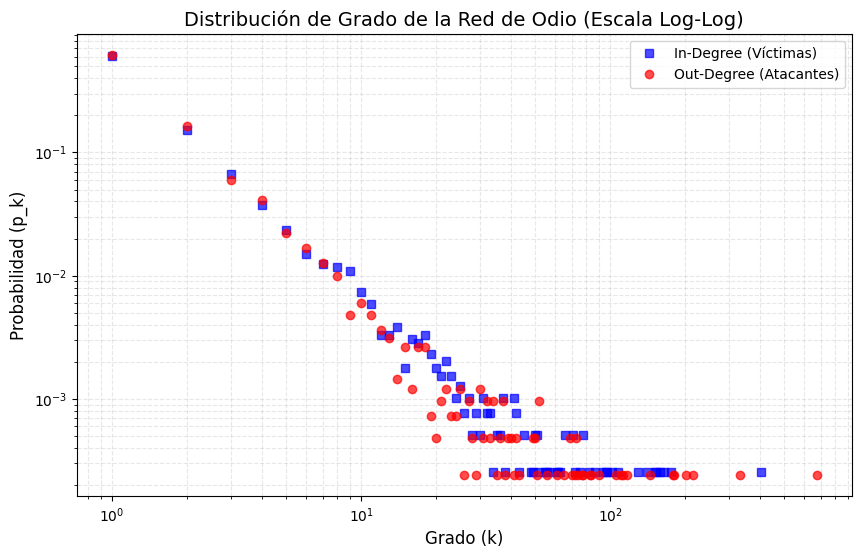

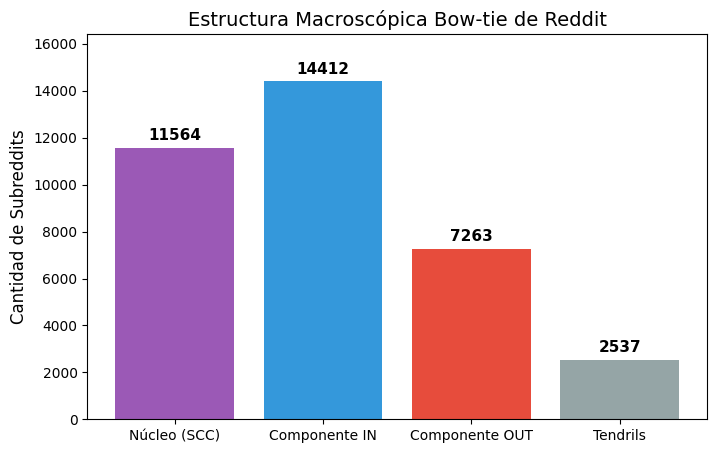

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# GRÁFICO 1: Distribución Log-Log de In-degree y Out-degree
in_degrees = [d for n, d in NEG_REDDIT.in_degree() if d > 0]
out_degrees = [d for n, d in NEG_REDDIT.out_degree() if d > 0]

# Contar frecuencias
in_counts = Counter(in_degrees)
out_counts = Counter(out_degrees)

# Convertir a listas para plotear
in_x, in_y = zip(*sorted(in_counts.items()))
out_x, out_y = zip(*sorted(out_counts.items()))

# Normalizar para obtener probabilidad pk
in_y = np.array(in_y) / sum(in_y)
out_y = np.array(out_y) / sum(out_y)

plt.figure(figsize=(10, 6))
plt.loglog(in_x, in_y, 's', color='blue', alpha=0.7, label='In-Degree (Víctimas)')
plt.loglog(out_x, out_y, 'o', color='red', alpha=0.7, label='Out-Degree (Atacantes)')

plt.title("Distribución de Grado de la Red de Odio (Escala Log-Log)", fontsize=14)
plt.xlabel("Grado (k)", fontsize=12)
plt.ylabel("Probabilidad (p_k)", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.savefig("distribucion_loglog_odio.png", dpi=300, bbox_inches='tight')
plt.show()

# GRÁFICO 2: Proporciones de la Estructura Bow-tie
etiquetas = ['Núcleo (SCC)', 'Componente IN', 'Componente OUT', 'Tendrils']
valores = [len(scc_nodes), len(in_component), len(out_component), len(tendrils)]
colores = ['#9b59b6', '#3498db', '#e74c3c', '#95a5a6']

plt.figure(figsize=(8, 5))
barras = plt.bar(etiquetas, valores, color=colores)

for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 200, 
             f'{yval}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Estructura Macroscópica Bow-tie de Reddit", fontsize=14)
plt.ylabel("Cantidad de Subreddits", fontsize=12)
plt.ylim(0, max(valores) + 2000)
plt.savefig("bowtie_reddit.png", dpi=300, bbox_inches='tight')
plt.show()